<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №10

In [ ]:
!pip install transformers --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 110.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [4]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm
from IPython.display import clear_output

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cpu


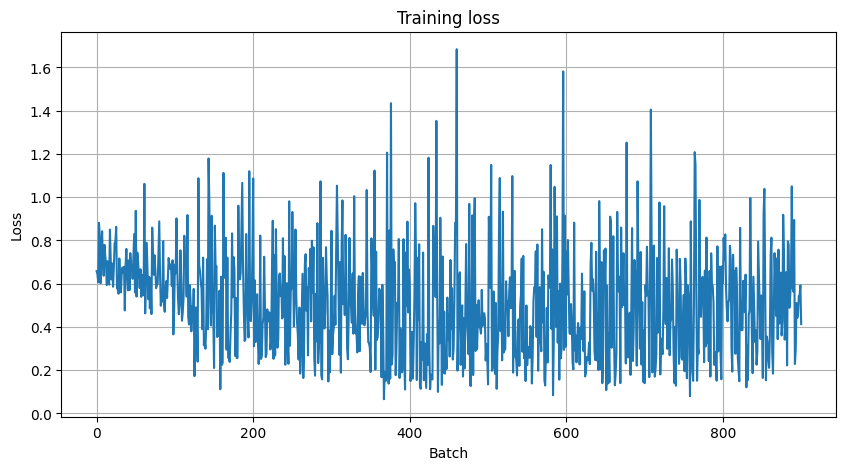

Loss на навчальній вибірці: 0.50546


Validation:   0%|          | 0/280 [00:00<?, ?it/s]

Відсоток правильних передбачень на валідаційній вибірці: 78.50%


Testing:   0%|          | 0/1200 [00:00<?, ?it/s]

Відсоток правильних передбачень на відкладеній вибірці: 80.20%
Невірних передбачень: 1188/6000

Приклади помилок моделі:

Помилка 1
Текст: [CLS] @colortheory We're at 100% taken apart  [SEP]
Істинна мітка: 0
Передбачена мітка: 1
--------------------------------------------------------------------------------
Помилка 2
Текст: [CLS] Going to bed early. Photoshoot tomorrow  [SEP]
Істинна мітка: 1
Передбачена мітка: 0
--------------------------------------------------------------------------------
Помилка 3
Текст: [CLS] Just letting my flock know I'm still alive  at dinner w hubby in hilton head. Still very much on vacay! [SEP]
Істинна мітка: 1
Передбачена мітка: 0
--------------------------------------------------------------------------------
Помилка 4
Текст: [CLS] You're such a shit muffin  muahaha. [SEP]
Істинна мітка: 1
Передбачена мітка: 0
--------------------------------------------------------------------------------
Помилка 5
Текст: [CLS] @israelod not to me  lol [SEP]
Істинна міт

In [4]:
df = pd.read_csv("sentiment.csv", encoding="latin1", header=None)
print(df.head())
print("Shape:", df.shape)
print("Label counts:")
print(df[0].value_counts())

df.columns = ["sentiment", "id", "date", "query", "user", "text"]

unique_labels = sorted(df["sentiment"].unique().tolist())
print("Unique labels:", unique_labels)

if 4 in unique_labels and 0 in unique_labels:
    pos_label = 4
    neg_label = 0
elif 1 in unique_labels and 0 in unique_labels:
    pos_label = 1
    neg_label = 0
else:
    raise ValueError(f"Невідомий формат міток: {unique_labels}")

pos_texts = df.loc[df.sentiment == pos_label].reset_index(drop=True)
neg_texts = df.loc[df.sentiment == neg_label].reset_index(drop=True)

print("Позитивних до вибірки:", len(pos_texts))
print("Негативних до вибірки:", len(neg_texts))

sample_size = 10000
sample_size = min(sample_size, len(pos_texts), len(neg_texts))

pos_texts = pos_texts.sample(sample_size, random_state=42).reset_index(drop=True)
neg_texts = neg_texts.sample(sample_size, random_state=42).reset_index(drop=True)

print("Позитивних після вибірки:", len(pos_texts))
print("Негативних після вибірки:", len(neg_texts))

sample_n = min(5, len(pos_texts))
print(pos_texts.sample(sample_n, random_state=42))

sentences = np.concatenate([pos_texts["text"].astype(str).values, neg_texts["text"].astype(str).values])
sentences = ["[CLS] " + sentence + " [SEP]" for sentence in sentences]
labels = [1 for _ in range(pos_texts.shape[0])] + [0 for _ in range(neg_texts.shape[0])]

assert len(sentences) == len(labels)

print(sentences[min(1000, len(sentences) - 1)])

train_sentences, test_sentences, train_gt, test_gt = train_test_split(
    sentences,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

print("Train size:", len(train_gt))
print("Test size:", len(test_gt))

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

max_len = 100
batch_size = 5

train_encodings = tokenizer(
    train_sentences,
    add_special_tokens=False,
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_attention_mask=True
)

input_ids = train_encodings["input_ids"]
attention_masks = train_encodings["attention_mask"]

train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids,
    train_gt,
    random_state=42,
    test_size=0.1,
    stratify=train_gt
)

train_masks, validation_masks, _, _ = train_test_split(
    attention_masks,
    train_gt,
    random_state=42,
    test_size=0.1,
    stratify=train_gt
)

train_inputs = torch.tensor(train_inputs)
train_labels = torch.tensor(train_labels)
train_masks = torch.tensor(train_masks)

validation_inputs = torch.tensor(validation_inputs)
validation_labels = torch.tensor(validation_labels)
validation_masks = torch.tensor(validation_masks)

print(train_labels[:10])

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_dataloader = DataLoader(
    train_data,
    sampler=RandomSampler(train_data),
    batch_size=batch_size
)

validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_dataloader = DataLoader(
    validation_data,
    sampler=SequentialSampler(validation_data),
    batch_size=batch_size
)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
model.to(DEVICE)

param_optimizer = list(model.named_parameters())
no_decay = ["bias", "gamma", "beta", "LayerNorm.weight"]

optimizer_grouped_parameters = [
    {
        "params": [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01
    },
    {
        "params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0
    }
]

optimizer = AdamW(optimizer_grouped_parameters, lr=2e-5)

train_loss_set = []
train_loss = 0.0
max_train_steps = 1000

model.train()

for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    if step >= max_train_steps:
        break

    batch = tuple(t.to(DEVICE) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    optimizer.zero_grad()

    outputs = model(
        b_input_ids,
        token_type_ids=None,
        attention_mask=b_input_mask,
        labels=b_labels
    )

    loss = outputs.loss
    train_loss_set.append(loss.item())

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

    if step % 100 == 0:
        clear_output(True)
        plt.figure(figsize=(10, 5))
        plt.plot(train_loss_set)
        plt.title("Training loss")
        plt.xlabel("Batch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

print("Loss на навчальній вибірці: {0:.5f}".format(train_loss / max_train_steps))

model.eval()

valid_preds, valid_labels = [], []

for batch in tqdm(validation_dataloader, desc="Validation"):
    batch = tuple(t.to(DEVICE) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask
        )

    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.cpu().numpy()
    batch_preds = np.argmax(logits, axis=1)

    valid_preds.extend(batch_preds.tolist())
    valid_labels.extend(label_ids.tolist())

val_acc = accuracy_score(valid_labels, valid_preds)
print("Відсоток правильних передбачень на валідаційній вибірці: {0:.2f}%".format(val_acc * 100))

test_encodings = tokenizer(
    test_sentences,
    add_special_tokens=False,
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_attention_mask=True
)

prediction_inputs = torch.tensor(test_encodings["input_ids"])
prediction_masks = torch.tensor(test_encodings["attention_mask"])
prediction_labels = torch.tensor(test_gt)

prediction_data = TensorDataset(
    prediction_inputs,
    prediction_masks,
    prediction_labels
)

prediction_dataloader = DataLoader(
    prediction_data,
    sampler=SequentialSampler(prediction_data),
    batch_size=batch_size
)

model.eval()

test_preds, test_labels = [], []

for batch in tqdm(prediction_dataloader, desc="Testing"):
    batch = tuple(t.to(DEVICE) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask
        )

    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.cpu().numpy()
    batch_preds = np.argmax(logits, axis=1)

    test_preds.extend(batch_preds.tolist())
    test_labels.extend(label_ids.tolist())

acc_score = accuracy_score(test_labels, test_preds)

print("Відсоток правильних передбачень на відкладеній вибірці: {0:.2f}%".format(acc_score * 100))
print("Невірних передбачень: {0}/{1}".format(sum(np.array(test_labels) != np.array(test_preds)), len(test_labels)))

misclassified = []

for text, true_label, pred_label in zip(test_sentences, test_labels, test_preds):
    if true_label != pred_label:
        misclassified.append((text, true_label, pred_label))

print("\nПриклади помилок моделі:\n")

for i, (text, true_label, pred_label) in enumerate(misclassified[:10], 1):
    print(f"Помилка {i}")
    print("Текст:", text)
    print("Істинна мітка:", true_label)
    print("Передбачена мітка:", pred_label)
    print("-" * 80)

##Завантажте IMDB Dataset

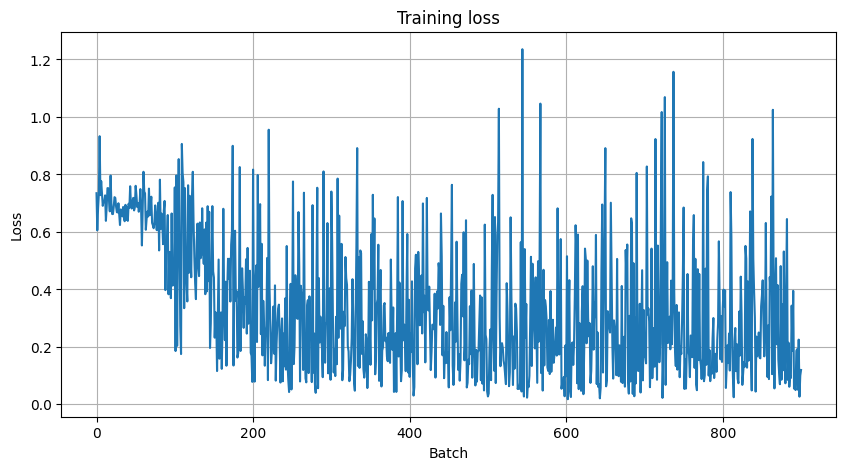

Loss на навчальній вибірці: 0.33723


Validation:   0%|          | 0/438 [00:00<?, ?it/s]

Відсоток правильних передбачень на валідаційній вибірці: 90.06%


Testing:   0%|          | 0/1875 [00:00<?, ?it/s]

Відсоток правильних передбачень на відкладеній вибірці: 90.01%
Невірних передбачень: 1498/15000

Приклади помилок моделі:

Помилка 1
Текст: [CLS] There are two kinds of characters on THE SHIELD: people who try to do the best they can and do the right thing, and people who relentlessly pursue their own self interest and commit every mortal sin they can while telling themselves and everyone else that they are heroes, and everyone's only hope. More than any other show, THE SHIELD is about hypocrisy and self-delusion. Unfortunately, the hypocrites and self-deluders are the shows heroes, and as such have the typical genre-fiction heroes' improbable immunity to getting defeated or caught and they come out on top over and over again, making fools out of all of their peers.<br /><br />The show boasts excellent camera-work. The lead ins 
Істинна мітка: 0
Передбачена мітка: 1
--------------------------------------------------------------------------------
Помилка 2
Текст: [CLS] 'Major Payne' is 

In [7]:
dataset = pd.read_csv("IMDB Dataset.csv")
print(dataset.head())
print(dataset.shape)
print(dataset["sentiment"].value_counts())

dataset["review"] = dataset["review"].astype(str)
dataset["sentiment"] = dataset["sentiment"].map({"negative": 0, "positive": 1})

print(dataset.head())
print(dataset["sentiment"].value_counts())

sentences = dataset["review"].values
sentences = ["[CLS] " + sentence + " [SEP]" for sentence in sentences]
labels = dataset["sentiment"].values

train_sentences, test_sentences, train_gt, test_gt = train_test_split(
    sentences,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

print("Train size:", len(train_gt))
print("Test size:", len(test_gt))

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

max_len = 256
batch_size = 8

train_encodings = tokenizer(
    train_sentences,
    add_special_tokens=False,
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_attention_mask=True
)

input_ids = train_encodings["input_ids"]
attention_masks = train_encodings["attention_mask"]

train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids,
    train_gt,
    random_state=42,
    test_size=0.1,
    stratify=train_gt
)

train_masks, validation_masks, _, _ = train_test_split(
    attention_masks,
    train_gt,
    random_state=42,
    test_size=0.1,
    stratify=train_gt
)

train_inputs = torch.tensor(train_inputs)
train_labels = torch.tensor(train_labels)
train_masks = torch.tensor(train_masks)

validation_inputs = torch.tensor(validation_inputs)
validation_labels = torch.tensor(validation_labels)
validation_masks = torch.tensor(validation_masks)

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_dataloader = DataLoader(
    train_data,
    sampler=RandomSampler(train_data),
    batch_size=batch_size
)

validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_dataloader = DataLoader(
    validation_data,
    sampler=SequentialSampler(validation_data),
    batch_size=batch_size
)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
model.to(DEVICE)

param_optimizer = list(model.named_parameters())
no_decay = ["bias", "gamma", "beta", "LayerNorm.weight"]

optimizer_grouped_parameters = [
    {
        "params": [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01
    },
    {
        "params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0
    }
]

optimizer = AdamW(optimizer_grouped_parameters, lr=2e-5)

train_loss_set = []
train_loss = 0.0
max_train_steps = 1000

model.train()

for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    if step >= max_train_steps:
        break

    batch = tuple(t.to(DEVICE) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    optimizer.zero_grad()

    outputs = model(
        b_input_ids,
        token_type_ids=None,
        attention_mask=b_input_mask,
        labels=b_labels
    )

    loss = outputs.loss
    train_loss_set.append(loss.item())

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

    if step % 100 == 0:
        clear_output(True)
        plt.figure(figsize=(10, 5))
        plt.plot(train_loss_set)
        plt.title("Training loss")
        plt.xlabel("Batch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

print("Loss на навчальній вибірці: {0:.5f}".format(train_loss / max_train_steps))

model.eval()

valid_preds, valid_labels = [], []

for batch in tqdm(validation_dataloader, desc="Validation"):
    batch = tuple(t.to(DEVICE) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask
        )

    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.cpu().numpy()
    batch_preds = np.argmax(logits, axis=1)

    valid_preds.extend(batch_preds.tolist())
    valid_labels.extend(label_ids.tolist())

val_acc = accuracy_score(valid_labels, valid_preds)
print("Відсоток правильних передбачень на валідаційній вибірці: {0:.2f}%".format(val_acc * 100))

test_encodings = tokenizer(
    test_sentences,
    add_special_tokens=False,
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_attention_mask=True
)

prediction_inputs = torch.tensor(test_encodings["input_ids"])
prediction_masks = torch.tensor(test_encodings["attention_mask"])
prediction_labels = torch.tensor(test_gt)

prediction_data = TensorDataset(
    prediction_inputs,
    prediction_masks,
    prediction_labels
)

prediction_dataloader = DataLoader(
    prediction_data,
    sampler=SequentialSampler(prediction_data),
    batch_size=batch_size
)

model.eval()

test_preds, test_labels = [], []

for batch in tqdm(prediction_dataloader, desc="Testing"):
    batch = tuple(t.to(DEVICE) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask
        )

    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.cpu().numpy()
    batch_preds = np.argmax(logits, axis=1)

    test_preds.extend(batch_preds.tolist())
    test_labels.extend(label_ids.tolist())

acc_score = accuracy_score(test_labels, test_preds)

print("Відсоток правильних передбачень на відкладеній вибірці: {0:.2f}%".format(acc_score * 100))
print("Невірних передбачень: {0}/{1}".format(sum(np.array(test_labels) != np.array(test_preds)), len(test_labels)))

misclassified = []

for text, true_label, pred_label in zip(test_sentences, test_labels, test_preds):
    if true_label != pred_label:
        misclassified.append((text, true_label, pred_label))

print("\nПриклади помилок моделі:\n")

for i, (text, true_label, pred_label) in enumerate(misclassified[:10], 1):
    print(f"Помилка {i}")
    print("Текст:", text[:700])
    print("Істинна мітка:", true_label)
    print("Передбачена мітка:", pred_label)
    print("-" * 80)

##Експерименти з параметрами. Змінюйте максимальну довжину текстів (max_len). Порівняйте, як це впливає на результати моделі. Змінюйте розмір батчу (batch_size).

In [6]:
import time

In [8]:
ataset = pd.read_csv("IMDB Dataset.csv")
dataset["review"] = dataset["review"].astype(str)
dataset["sentiment"] = dataset["sentiment"].map({"negative": 0, "positive": 1})

sample_size = 4000
dataset = dataset.sample(sample_size, random_state=42).reset_index(drop=True)

sentences = dataset["review"].tolist()
sentences = ["[CLS] " + sentence + " [SEP]" for sentence in sentences]
labels = dataset["sentiment"].tolist()

train_sentences, test_sentences, train_gt, test_gt = train_test_split(
    sentences,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

def build_loaders(train_sentences, train_gt, test_sentences, test_gt, max_len, batch_size):
    train_encodings = tokenizer(
        train_sentences,
        add_special_tokens=False,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_attention_mask=True
    )

    input_ids = train_encodings["input_ids"]
    attention_masks = train_encodings["attention_mask"]

    train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
        input_ids,
        train_gt,
        random_state=42,
        test_size=0.1,
        stratify=train_gt
    )

    train_masks, validation_masks, _, _ = train_test_split(
        attention_masks,
        train_gt,
        random_state=42,
        test_size=0.1,
        stratify=train_gt
    )

    train_inputs = torch.tensor(train_inputs)
    train_labels = torch.tensor(train_labels)
    train_masks = torch.tensor(train_masks)

    validation_inputs = torch.tensor(validation_inputs)
    validation_labels = torch.tensor(validation_labels)
    validation_masks = torch.tensor(validation_masks)

    train_data = TensorDataset(train_inputs, train_masks, train_labels)
    train_dataloader = DataLoader(
        train_data,
        sampler=RandomSampler(train_data),
        batch_size=batch_size
    )

    validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
    validation_dataloader = DataLoader(
        validation_data,
        sampler=SequentialSampler(validation_data),
        batch_size=batch_size
    )

    test_encodings = tokenizer(
        test_sentences,
        add_special_tokens=False,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_attention_mask=True
    )

    prediction_inputs = torch.tensor(test_encodings["input_ids"])
    prediction_masks = torch.tensor(test_encodings["attention_mask"])
    prediction_labels = torch.tensor(test_gt)

    prediction_data = TensorDataset(
        prediction_inputs,
        prediction_masks,
        prediction_labels
    )

    prediction_dataloader = DataLoader(
        prediction_data,
        sampler=SequentialSampler(prediction_data),
        batch_size=batch_size
    )

    return train_dataloader, validation_dataloader, prediction_dataloader

def create_model():
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )
    model.to(DEVICE)

    param_optimizer = list(model.named_parameters())
    no_decay = ["bias", "gamma", "beta", "LayerNorm.weight"]

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01
        },
        {
            "params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0
        }
    ]

    optimizer = AdamW(optimizer_grouped_parameters, lr=2e-5)
    return model, optimizer

def evaluate_model(model, dataloader):
    model.eval()
    preds, true_labels = [], []

    for batch in tqdm(dataloader, leave=False):
        batch = tuple(t.to(DEVICE) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask
            )

        logits = outputs.logits.detach().cpu().numpy()
        label_ids = b_labels.cpu().numpy()
        batch_preds = np.argmax(logits, axis=1)

        preds.extend(batch_preds.tolist())
        true_labels.extend(label_ids.tolist())

    return accuracy_score(true_labels, preds)

def train_and_evaluate(max_len, batch_size, epochs):
    train_dataloader, validation_dataloader, prediction_dataloader = build_loaders(
        train_sentences, train_gt, test_sentences, test_gt, max_len, batch_size
    )

    model, optimizer = create_model()

    train_losses = []
    start_time = time.time()
    max_batches = 200

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        processed_batches = 0

        for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)):
            if step >= max_batches:
                break

            batch = tuple(t.to(DEVICE) for t in batch)
            b_input_ids, b_input_mask, b_labels = batch

            optimizer.zero_grad()

            outputs = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask,
                labels=b_labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            processed_batches += 1

        avg_train_loss = total_loss / processed_batches
        train_losses.append(avg_train_loss)

    training_time = time.time() - start_time

    val_acc = evaluate_model(model, validation_dataloader)
    test_acc = evaluate_model(model, prediction_dataloader)

    return {
        "max_len": max_len,
        "batch_size": batch_size,
        "epochs": epochs,
        "train_loss": train_losses[-1],
        "val_acc": val_acc,
        "test_acc": test_acc,
        "time_sec": training_time,
        "loss_history": train_losses
    }

results = []

max_len_values = [64, 128]
batch_size_values = [8, 16]
epoch_values = [2, 5]

for max_len in max_len_values:
    results.append(train_and_evaluate(max_len=max_len, batch_size=8, epochs=2))

for batch_size in batch_size_values:
    results.append(train_and_evaluate(max_len=128, batch_size=batch_size, epochs=2))

for epochs in epoch_values:
    results.append(train_and_evaluate(max_len=128, batch_size=8, epochs=epochs))

results_df = pd.DataFrame(results)

print(results_df[["max_len", "batch_size", "epochs", "train_loss", "val_acc", "test_acc", "time_sec"]])

print("\nЕксперименти з max_len:")
print(
    results_df[
        (results_df["batch_size"] == 8) &
        (results_df["epochs"] == 2)
    ][["max_len", "val_acc", "test_acc", "time_sec"]]
)

print("\nЕксперименти з batch_size:")
print(
    results_df[
        (results_df["max_len"] == 128) &
        (results_df["epochs"] == 2)
    ][["batch_size", "val_acc", "test_acc", "time_sec"]]
)

print("\nЕксперименти з epochs:")
print(
    results_df[
        (results_df["max_len"] == 128) &
        (results_df["batch_size"] == 8)
    ][["epochs", "val_acc", "test_acc", "time_sec"]]
)

plt.figure(figsize=(10, 5))
for row in results:
    if row["max_len"] == 128 and row["batch_size"] == 8:
        plt.plot(
            range(1, len(row["loss_history"]) + 1),
            row["loss_history"],
            marker="o",
            label=f'epochs={row["epochs"]}'
        )

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Порівняння train loss для різної кількості епох")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'dataset' is not defined

### Змінюйте розмір батчу (batch_size). Оцініть вплив на час тренування та якість. Порівняйте результати моделі при навчанні 2, 5 та 10 епох.

На жаль, на цьому етапі закінчився ліміт безкоштовного GPU та процес перервався, намагався запустити на CPU, але це вічність

##Контрольні питання

###1. Що таке BERT і для яких задач його найчастіше використовують?
BERT — це трансформерна мовна модель, яка використовується для задач класифікації тексту, NER, аналізу тональності, відповіді на запитання та інших NLP-задач.
###2. Яку роль виконують спеціальні токени [CLS] та [SEP] у BERT? Чому вони додаються до тексту перед подачею на модель?
[CLS] — спеціальний токен для отримання узагальненого представлення всього тексту (використовується для класифікації), [SEP] — розділяє речення або позначає кінець послідовності.
###3. Що таке "attention mask" і для чого вона потрібна?
Attention mask — це маска, яка показує моделі, які токени є реальними, а які — padding, щоб модель не враховувала зайві символи.
###4. Яка структура входів у BERT і які типи даних подаються на вхід моделі?
На вхід BERT подаються токенізовані послідовності у вигляді числових індексів, а також додаткові маски та сегментні індекси.
###5. Поясніть, що таке input_ids, token_type_ids та attention_mask.
input_ids — індекси токенів у словнику, token_type_ids — показують, до якого речення належить токен, attention_mask — визначає, які токени потрібно враховувати під час обчислень.